In [6]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/ieee-fraud-detection/sample_submission.csv
/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv
/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv


In [7]:
pip install mlflow dagshub

Note: you may need to restart the kernel to use updated packages.


In [8]:
import dagshub
import mlflow
import mlflow.sklearn

#dagshub.init(repo_owner='YOUR_DAGSHUB_USERNAME', repo_name='YOUR_REPO_NAME', mlflow=True)
dagshub.init(repo_owner='mkhak23', repo_name='ML_assignment2', mlflow=True)

Accessing as mkhak23

Initialized MLflow to track repo "mkhak23/ML_assignment2"

Repository mkhak23/ML_assignment2 initialized!

# Exploratory Data Analysis (EDA)

In [9]:
identity = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv')
transaction = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv')

In [10]:
from sklearn.model_selection import train_test_split

train = transaction.merge(identity, on = 'TransactionID', how = 'left')

X = train.drop(columns=["isFraud","TransactionID"])
y = train["isFraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape}")
print(f"Test size:  {X_test.shape}")

Train size: (472432, 432)
Test size:  (118108, 432)


In [11]:
print(X_train.describe())

       TransactionDT  TransactionAmt          card1          card2  \
count   4.724320e+05   472432.000000  472432.000000  465285.000000   
mean    7.373394e+06      135.071756    9903.027720     362.527137   
std     4.616510e+06      241.371497    4902.685441     157.783396   
min     8.640000e+04        0.251000    1001.000000     100.000000   
25%     3.028537e+06       43.140000    6019.000000     214.000000   
50%     7.309639e+06       68.911000    9689.000000     361.000000   
75%     1.124764e+07      125.000000   14203.000000     512.000000   
max     1.581113e+07    31937.391000   18396.000000     600.000000   

               card3         card5          addr1          addr2  \
count  471197.000000  469035.00000  419709.000000  419709.000000   
mean      153.203514     199.30153     290.762967      86.799525   
std        11.353198      41.21739     101.785679       2.709423   
min       100.000000     100.00000     100.000000      10.000000   
25%       150.000000     166.

In [12]:
print(X_train.isnull().sum())

TransactionDT          0
TransactionAmt         0
ProductCD              0
card1                  0
card2               7147
                   ...  
id_36             359347
id_37             359347
id_38             359347
DeviceType        359497
DeviceInfo        377225
Length: 432, dtype: int64


In [13]:
print(X_train.info())

<class 'pandas.core.frame.DataFrame'>
Index: 472432 entries, 40809 to 337290
Columns: 432 entries, TransactionDT to DeviceInfo
dtypes: float64(399), int64(2), object(31)
memory usage: 1.5+ GB
None


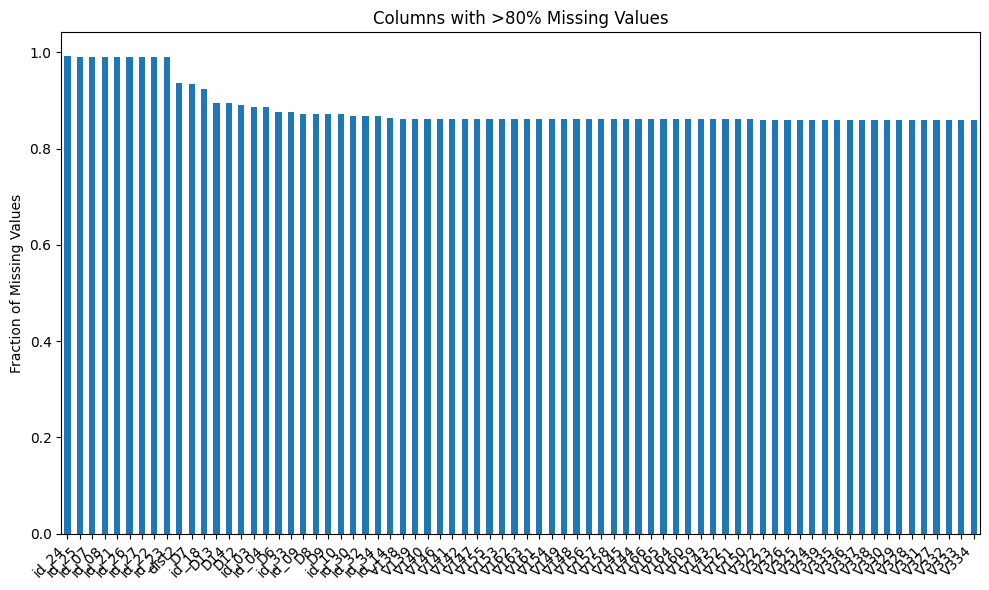

In [14]:
import matplotlib.pyplot as plt

null_ratio = X_train.isna().sum() / X_train.shape[0]

# keep only columns with > 80% missing
null_ratio = null_ratio[null_ratio > 0.8].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
null_ratio.plot(kind='bar')
plt.title('Columns with >80% Missing Values')
plt.ylabel('Fraction of Missing Values')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# **Data Cleaning**

In [15]:
# import pandas as pd
# from sklearn.base import BaseEstimator, TransformerMixin

# class MergeAndDropHighNaN(BaseEstimator, TransformerMixin):
#     def __init__(self, other_df, key="TransactionID", nan_threshold=0.95):
#         self.other_df = other_df
#         self.key = key
#         self.nan_threshold = nan_threshold
#         self.cols_to_drop_ = None

#     def fit(self, X, y=None):
#         # Compute columns with high NaN ratio from X ONLY (train)
#         nan_ratio = X.isna().mean()
#         self.cols_to_drop_ = nan_ratio[nan_ratio > self.nan_threshold].index.tolist()
#         return self

#     def transform(self, X):
#         X = X.copy()

#         # Drop high-missing columns
#         X = X.drop(columns=self.cols_to_drop_, errors="ignore")

#         # Merge with other dataframe
#         merged = X.merge(self.other_df, on=self.key, how="left")
#         merged = merged.drop(columns=['TransactionID'])

#         return merged

# **Feature Engineering**

In [16]:
from sklearn.preprocessing import OneHotEncoder
from scipy import sparse
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin

class CategoricalOHE(BaseEstimator, TransformerMixin):
    def __init__(self, cols=None, max_categories=50):
        self.cols = cols
        self.max_categories = max_categories
        self.encoder = OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=True,
            max_categories=max_categories
        )

    def fit(self, X, y=None):
        X = X.copy()

        if self.cols is None:
            self.cols_ = X.select_dtypes(include=["object"]).columns.tolist()
        else:
            self.cols_ = self.cols

        X_cat = X[self.cols_].fillna("missing")
        self.encoder.fit(X_cat)

        return self

    def transform(self, X):
        X = X.copy()

        X_cat = X[self.cols_].fillna("missing")
        X_ohe = self.encoder.transform(X_cat)

        X_num = X.drop(columns=self.cols_)

        # convert numeric part to sparse too
        X_num_sparse = sparse.csr_matrix(X_num.to_numpy())

        return sparse.hstack([X_num_sparse, X_ohe]).tocsr()

In [17]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin

class FraudFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, uid_cols=("card1", "addr1")):
        self.uid_cols = uid_cols
        self.uid_means_ = None

    def fit(self, X, y=None):
        X = X.copy()

        # create uid
        uid = self._make_uid(X)

        # compute mean TransactionAmt per uid (TRAIN ONLY)
        self.uid_means_ = (
            pd.DataFrame({
                "uid": uid,
                "TransactionAmt": X["TransactionAmt"]
            })
            .groupby("uid")["TransactionAmt"]
            .mean()
        )

        return self

    def transform(self, X):
        X = X.copy()

        # 1. hour feature
        X["hour"] = (X["TransactionDT"] // 3600) % 24

        # 2. identity missing count
        id_cols = [col for col in X.columns if col.startswith("id_")]
        if id_cols:
            X["identity_missing"] = X[id_cols].isna().sum(axis=1)
        else:
            X["identity_missing"] = 0

        # 3. uid
        uid = self._make_uid(X)

        # map mean values from TRAIN
        uid_mean = uid.map(self.uid_means_)

        # fallback for unseen users
        global_mean = self.uid_means_.mean()
        uid_mean = uid_mean.fillna(global_mean)

        X["uid_amt_mean"] = uid_mean

        # 4. deviation feature
        X["uid_amt_diff"] = X["TransactionAmt"] - X["uid_amt_mean"]

        return X

    def _make_uid(self, X):
        uid = X[self.uid_cols[0]].astype(str)
        for col in self.uid_cols[1:]:
            uid += "_" + X[col].astype(str)
        return uid

# **Feature Selection**

In [18]:
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin

class UselessFeatureDropper(BaseEstimator, TransformerMixin):
    def __init__(self,  variance_threshold=0.0):
        self.variance_threshold = variance_threshold
        self.cols_to_drop_ = []

    def fit(self, X, y=None):
        X = X.copy()
        self.cols_to_drop_ = []

        # 2. Drop constant columns
        constant_cols = [
            col for col in X.columns
            if X[col].nunique(dropna=False) <= 1
        ]

        # 3. Drop near-zero variance numeric columns
        numeric_cols = X.select_dtypes(include=["number"]).columns

        near_zero_var_cols = [
            col for col in numeric_cols
            if X[col].var(skipna=True) <= self.variance_threshold
        ]

        self.cols_to_drop_ = list(set(
            constant_cols + near_zero_var_cols
        ))

        return self

    def transform(self, X):
        X = X.copy()
        return X.drop(columns=self.cols_to_drop_, errors="ignore")

In [19]:
print(type(UselessFeatureDropper))
print(type(FraudFeatureEngineer))
print(type(CategoricalOHE))

<class 'type'>
<class 'type'>
<class 'type'>


# **XGBoost Model**

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
import xgboost as xgb

mlflow.set_experiment("xgboost")


scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

param_list = [
    {"max_depth": 4, "learning_rate": 0.05, "n_estimators": 500},
    {"max_depth": 6, "learning_rate": 0.05, "n_estimators": 500},
    {"max_depth": 8, "learning_rate": 0.03, "n_estimators": 800},
]

results = []
    
    # model = xgb.XGBClassifier(
    #         max_depth = 4,
    #         learning_rate = 0.05,
    #         n_estimators = 500,
    #         subsample=0.8,
    #         colsample_bytree=0.8,
    #         scale_pos_weight=scale_pos_weight,
    #         tree_method="hist",
    #         eval_metric="auc",
    #         random_state=42
    #     )

    # temp_pipeline = Pipeline([
    #         ("drop_useless", UselessFeatureDropper()),
    #         ("features", FraudFeatureEngineer()),
    #         ("cat_ohe", CategoricalOHE()),
    #         ("model", model)
    #     ])
    # temp_pipeline.fit(X_train, y_train)
    
    # preds = temp_pipeline.predict_proba(X_test)[:, 1]
    # auc = roc_auc_score(y_test, preds)
    # mlflow.log_param("max_depth",4)
    # mlflow.log_param("learning_rate" ,0.05)
    # mlflow.log_param("n_estimators", 500)
    # mlflow.log_param("scale_pos_weight", scale_pos_weight)
        
    
    # results.append({"max_depth": 4, "learning_rate": 0.05, "n_estimators": 500, "auc": auc})
    # print("AUC:", auc)
    
for params in param_list:
    with mlflow.start_run(run_name="XGBoost_training") as run:
        model = xgb.XGBClassifier(
            **params,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            tree_method="hist",
            eval_metric="auc",
            random_state=42
        )
    
        temp_pipeline = Pipeline([
            ("drop_useless", UselessFeatureDropper()),
            ("features", FraudFeatureEngineer()),
            ("cat_ohe", CategoricalOHE()),
            ("model", model)
        ])
        # for name, step in temp_pipeline.steps:
        #     print(name, type(step))
    
        temp_pipeline.fit(X_train, y_train)
    
        preds = temp_pipeline.predict_proba(X_test)[:, 1]
        y_pred = (preds >= 0.5).astype(int)
        auc = roc_auc_score(y_test, preds)
        mlflow.log_params(params)
        mlflow.log_metric("AUC",auc)
        mlflow.log_param("scale_pos_weight", scale_pos_weight)
        from sklearn.metrics import recall_score
        mlflow.log_metric("recall", recall_score(y_test, y_pred))
        from sklearn.metrics import f1_score
        mlflow.log_metric("f1", f1_score(y_test, y_pred))
        
    
        results.append({**params, "auc": auc})
        print(params, "AUC:", auc)
    
results_df = pd.DataFrame(results).sort_values("auc", ascending=False)
results_df

{'max_depth': 4, 'learning_rate': 0.05, 'n_estimators': 500} AUC: 0.9253322327627231
🏃 View run XGBoost_training at: https://dagshub.com/mkhak23/ML_assignment2.mlflow/#/experiments/0/runs/8fd25a7cc69b4858bd33c543edb8854c
🧪 View experiment at: https://dagshub.com/mkhak23/ML_assignment2.mlflow/#/experiments/0
{'max_depth': 6, 'learning_rate': 0.05, 'n_estimators': 500} AUC: 0.9480572340590055
🏃 View run XGBoost_training at: https://dagshub.com/mkhak23/ML_assignment2.mlflow/#/experiments/0/runs/21bacb9bdd57440dacaa515fa48acd8b
🧪 View experiment at: https://dagshub.com/mkhak23/ML_assignment2.mlflow/#/experiments/0
{'max_depth': 8, 'learning_rate': 0.03, 'n_estimators': 800} AUC: 0.9618289897749999
🏃 View run XGBoost_training at: https://dagshub.com/mkhak23/ML_assignment2.mlflow/#/experiments/0/runs/ba9243f222d14c0284b20aae4da0e6a6
🧪 View experiment at: https://dagshub.com/mkhak23/ML_assignment2.mlflow/#/experiments/0


,max_depth,learning_rate,n_estimators,auc
2,8,0.03,800,0.961829
1,6,0.05,500,0.948057
0,4,0.05,500,0.925332


In [35]:
best_params = results_df.iloc[0].to_dict()

# remove auc from dict
best_params.pop("auc")
best_params["max_depth"] = int(best_params["max_depth"])
best_params["n_estimators"] = int(best_params["n_estimators"])
best_params["learning_rate"] = float(best_params["learning_rate"])
print(best_params)

{'max_depth': 8, 'learning_rate': 0.03, 'n_estimators': 800}


In [36]:
X_full = train.drop(columns=["isFraud", "TransactionID"])
y_full = train["isFraud"]

scale_pos_weight = (y_full == 0).sum() / (y_full == 1).sum()

final_model = xgb.XGBClassifier(
    **best_params,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    tree_method="hist",
    eval_metric="auc",
    random_state=42,
)

final_pipeline = Pipeline([
    ("drop_useless", UselessFeatureDropper()),
    ("features", FraudFeatureEngineer()),
    ("cat_ohe", CategoricalOHE()),
    ("model", final_model)
])

final_pipeline.fit(X_full, y_full)

mlflow.set_experiment("xgboost")


with mlflow.start_run(run_name="final_best_model"):

    # log parameters
    mlflow.log_params(best_params)
    mlflow.log_param("scale_pos_weight", scale_pos_weight)

    # log model artifact
    mlflow.sklearn.log_model(
        final_pipeline,
        name="final_pipeline"
    )
    mlflow.log_metric("final_auc", auc)

2026/05/04 23:49:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run final_best_model at: https://dagshub.com/mkhak23/ML_assignment2.mlflow/#/experiments/0/runs/4f67ca2365e44eff9c6b01cd1eada7e4
🧪 View experiment at: https://dagshub.com/mkhak23/ML_assignment2.mlflow/#/experiments/0
